In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns


# This makes sure the outputs of transformers are pandas dataframes
# Setting it globally at the top makes the rest of the code cleaner
from sklearn import set_config
set_config(transform_output='pandas')

In [ ]:
file_id = "1lqFIwe8bZCo88rwa1FN5f-JvM8-QDBoU"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url, index_col=[0])
df.columns = df.columns.str.strip()
df = df.set_index(['name', 'artist'])
df= df.drop(columns=['type','duration_ms','key','time_signature','id','html'])

In [ ]:
df = df[~df.duplicated(keep='first')]


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)

In [ ]:
df_scaled

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
name,artist,,,,,,,,,,
Se Eu Quiser Falar Com Deus,Gilberto Gil,0.320842,-1.140476,-0.949747,-1.0,0.247078,1.052669,-0.003307,5.882353,-0.224532,-0.227380
Saudade De Bahia,Antônio Carlos Jobim,0.541749,-0.807143,-0.868390,0.0,-0.352254,0.212858,-0.003394,-0.124567,0.580042,0.158709
"Canta Canta, Minha Gente",Martinho Da Vila,0.828402,-0.019048,-0.605744,0.0,4.863105,0.628362,-0.003300,-0.006920,1.020790,-0.666526
Mulher Eu Sei,Chico César,0.444444,-1.637619,-1.767268,0.0,-0.143573,1.378381,-0.003335,1.806228,0.228690,-0.321487
Rosa Morena,Kurt Elling,0.302433,-1.473810,-2.045363,0.0,-0.295492,1.443524,-0.002875,-0.145329,-0.024948,0.050805
...,...,...,...,...,...,...,...,...,...,...,...
"1812 Festival Overture, Op. 49: 1812 Overture, Op. 49",Pyotr Ilyich Tchaikovsky,-0.878369,-1.591905,-2.634261,0.0,-0.140234,1.445285,1.083232,-0.289273,-0.724532,-0.819035
"Winter Fragments pour ensemble instrumental, sons de synthèse et dispositif électronique",Tristan Murail,-0.915187,-1.516667,-2.384928,0.0,-0.191987,1.336127,0.644021,-0.384775,-0.786902,-0.944685
"Schoenberg: 5 Orchestral Pieces, Op. 16: No. 3 Farben (Colours)",Arnold Schoenberg,-1.252860,-1.754929,-5.850598,0.0,-0.205342,1.505145,1.469251,-0.330796,-0.789189,-1.249097


In [ ]:
# Create an empty list to store the inertia scores
inertia_list = []

# Iterate over the range of cluster numbers
for k in range(2, 20):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(df_scaled)

    # Append the inertia score to the list
    inertia_list.append(myKMeans.inertia_)

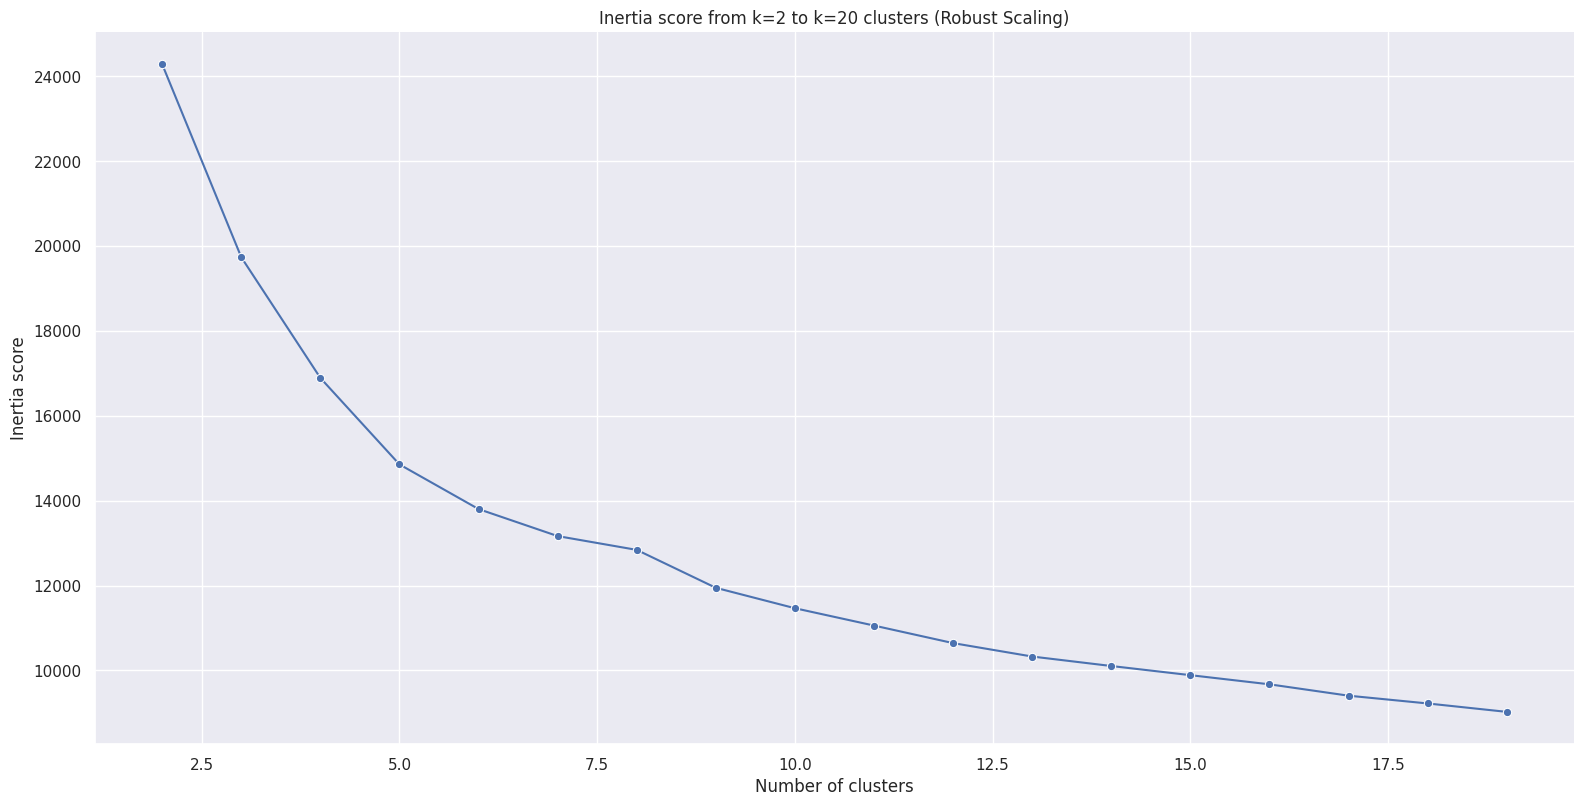

In [ ]:
# making grapf of inertia score
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list,
            x = range(2, 20),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from k=2 to k=20 clusters (Robust Scaling)")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);


In [ ]:
# Create an empty list to store the silhouette scores
sil_scores = []

for k in range(2,20):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(df_scaled)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(df_scaled, labels)

    # Append the silhouette score to the list
    sil_scores.append(sil_score)

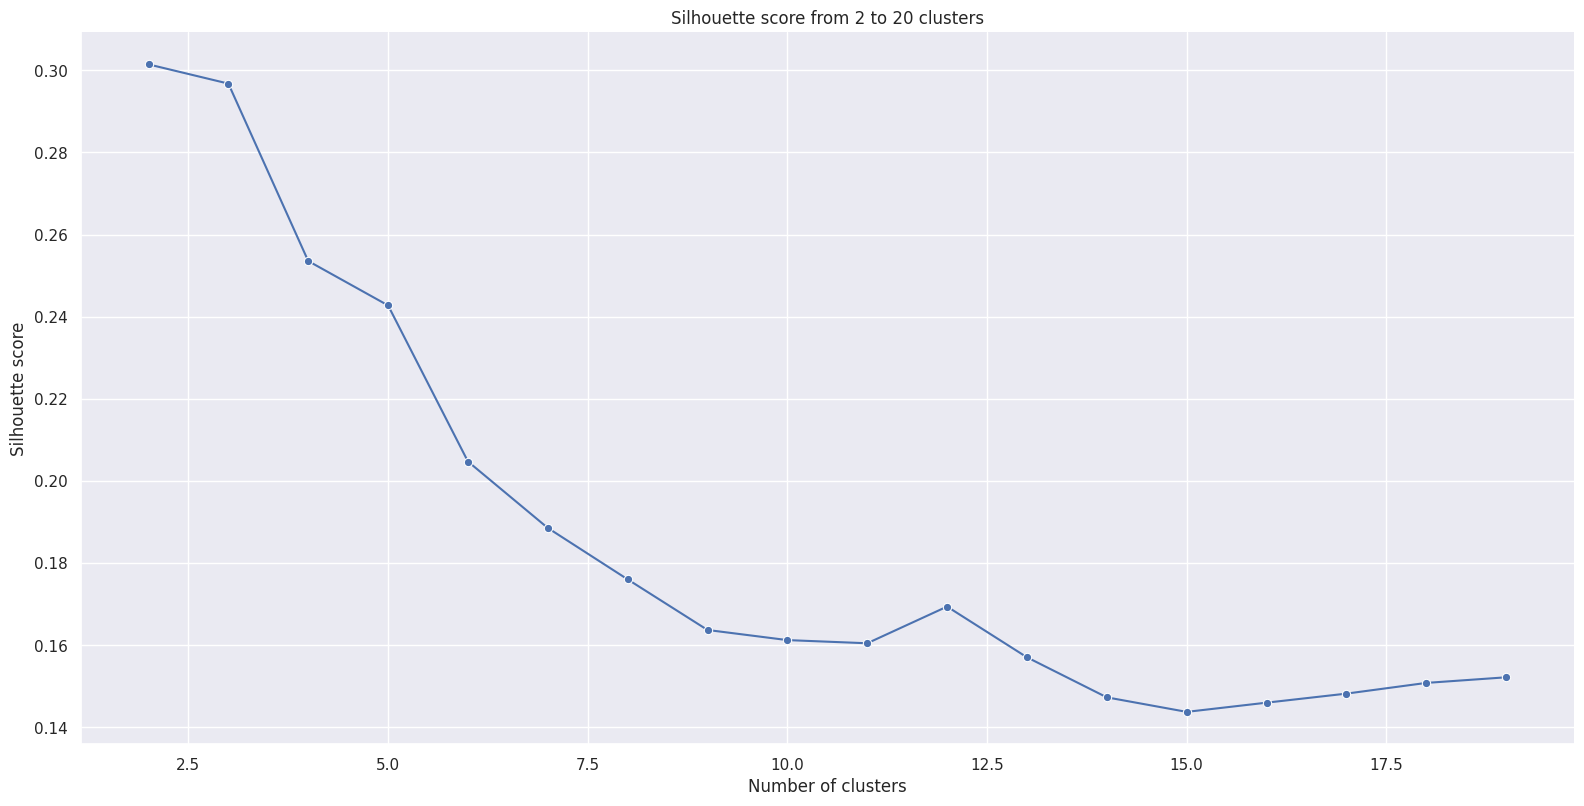

In [ ]:
(
sns.relplot(y = sil_scores,
            x = range(2, 20),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 2 to 20 clusters")
.set_axis_labels("Number of clusters", "Silhouette score")
);


In [ ]:
# Initialise the model
my_kmeans = KMeans(n_clusters = 8,
                   random_state = 42)

# Fit the model to the data
my_kmeans.fit(df_scaled)

# Obtain the cluster output
clusters = my_kmeans.labels_

# Attach the cluster output to our original DataFrame
df_scaled["cluster"] = clusters

In [ ]:
df_scaled.groupby(by="cluster").mean()

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,
0,-0.490683,-1.435117,-2.225078,-0.366667,-0.168963,1.444261,0.951332,0.017912,-0.451121,-0.370294
1,0.325336,-0.133134,0.085910,-1.000000,0.028717,0.218419,0.101915,-0.050358,0.323406,-0.003129
2,0.147553,0.170193,0.266553,-0.369710,2.304907,0.075253,0.148823,0.349896,0.157512,-0.071268
3,-0.723774,0.413549,-0.152050,-0.313901,0.715149,-0.159471,0.955933,0.314978,-0.410302,0.065271
4,0.218275,-0.218083,-0.051160,0.000000,-0.122894,0.312968,0.070445,-0.072313,0.392916,0.054638
5,-0.064068,-0.053830,-0.144887,-0.420290,0.584235,0.320758,0.267219,3.973288,0.080271,0.022418
6,0.214659,-0.037388,0.107666,-0.393939,4.862498,0.098651,0.101756,0.445360,0.218347,0.267239
7,0.078762,0.113830,0.195464,-0.313505,0.066842,0.110794,0.160600,1.506781,0.271768,0.176199


In [ ]:
df_scaled['cluster'].value_counts().sort_values()


,count
cluster,
6,165
5,207
2,449
7,622
1,729
0,810
3,892
4,1286


In [ ]:
bigplaylist= df_scaled.loc[df_scaled['cluster']==4]

In [ ]:
cluster4 = bigplaylist.drop(columns=['cluster'])

In [ ]:
cluster4

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
name,artist,,,,,,,,,,
Saudade De Bahia,Antônio Carlos Jobim,0.541749,-0.807143,-0.868390,0.0,-0.352254,0.212858,-0.003394,-0.124567,0.580042,0.158709
Brigas Nunca Mais,Paula Morelenbaum,0.415516,-0.457143,-0.672145,0.0,-0.262104,0.531528,0.112105,0.193772,0.471933,1.343414
Previsao,Bossacucanova,0.362919,0.300000,-0.100012,0.0,-0.292154,0.959356,0.540677,0.096886,0.253638,-0.500721
Nova Bossa Nova,Marcos Valle,0.163051,0.002381,-0.532440,0.0,-0.175292,0.751604,1.098429,0.145329,0.970894,-0.631769
Águas De Março,Antônio Carlos Jobim,0.270874,-0.442857,-0.315980,0.0,1.190317,1.295633,-0.003397,-0.020761,0.124740,0.637984
...,...,...,...,...,...,...,...,...,...,...,...
There Is More,Lexi,0.110454,-0.628571,-0.165263,0.0,-0.273790,0.836114,-0.003397,-0.103806,-0.010395,0.012889
Worth Fighting For - Live,Brian Courtney Wilson,-0.662722,-0.573810,-0.122036,0.0,0.457429,0.013909,-0.003397,-0.421453,-0.401247,1.488681
The Potter's House,Jerard & Jovaun,0.173570,-0.423810,-0.009122,0.0,-0.116861,0.036797,-0.003381,0.076125,0.534304,0.341445


In [ ]:
# Create an empty list to store the inertia scores
inertia_list_cluster4 = []

# Iterate over the range of cluster numbers
for k in range(2, 20):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(cluster4)

    # Append the inertia score to the list
    inertia_list_cluster4.append(myKMeans.inertia_)

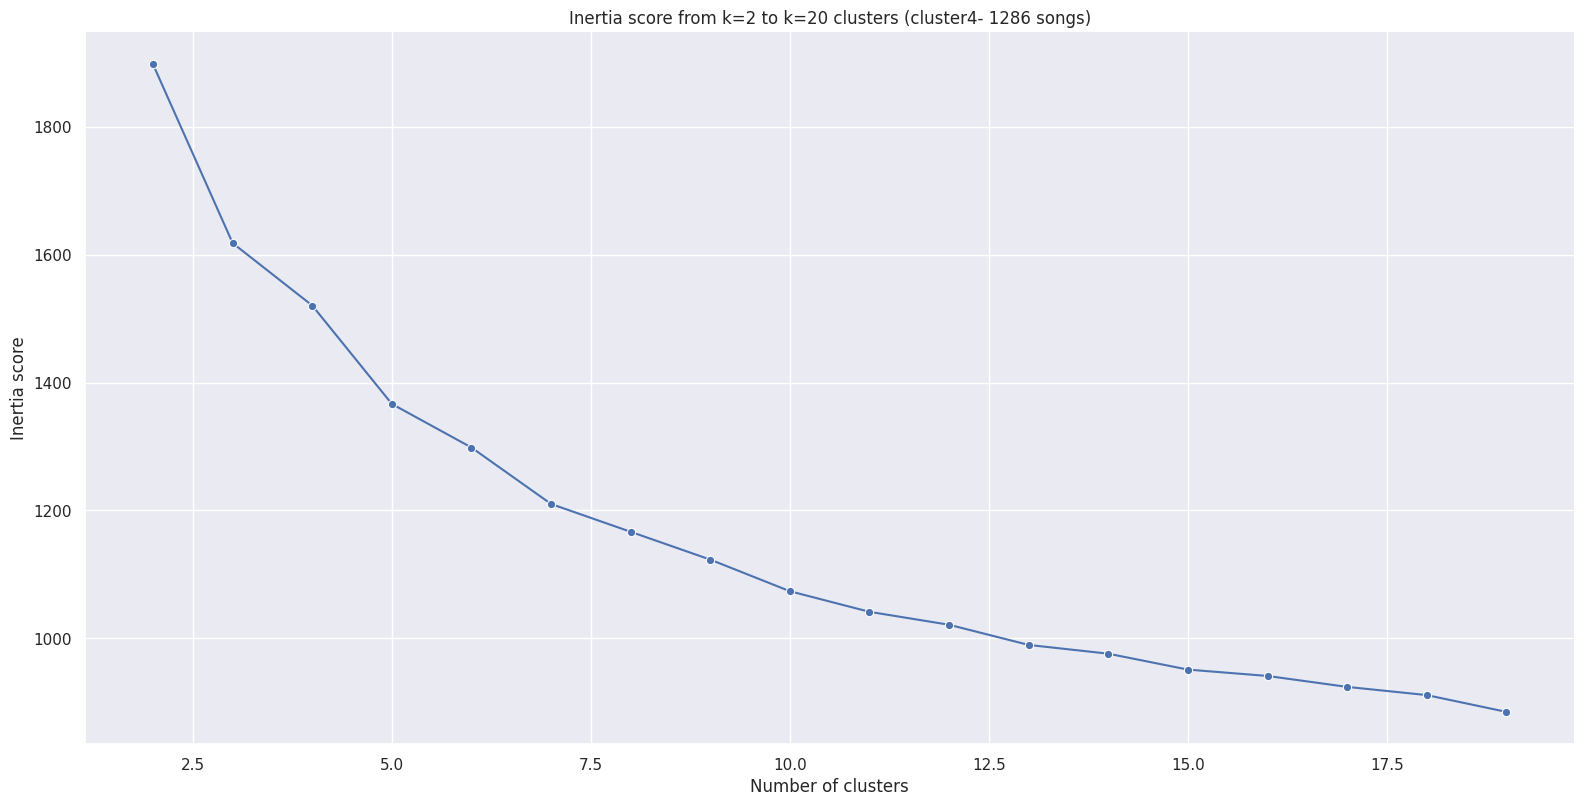

In [ ]:
# making grapf of inertia score
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list_cluster4,
            x = range(2, 20),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from k=2 to k=20 clusters (cluster4- 1286 songs)")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

#maybe k= 7 could be best option


In [ ]:
# Create an empty list to store the silhouette scores
sil_scores_cluster4 = []

for k in range(2,20):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(cluster4)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(cluster4, labels)

    # Append the silhouette score to the list
    sil_scores_cluster4.append(sil_score)

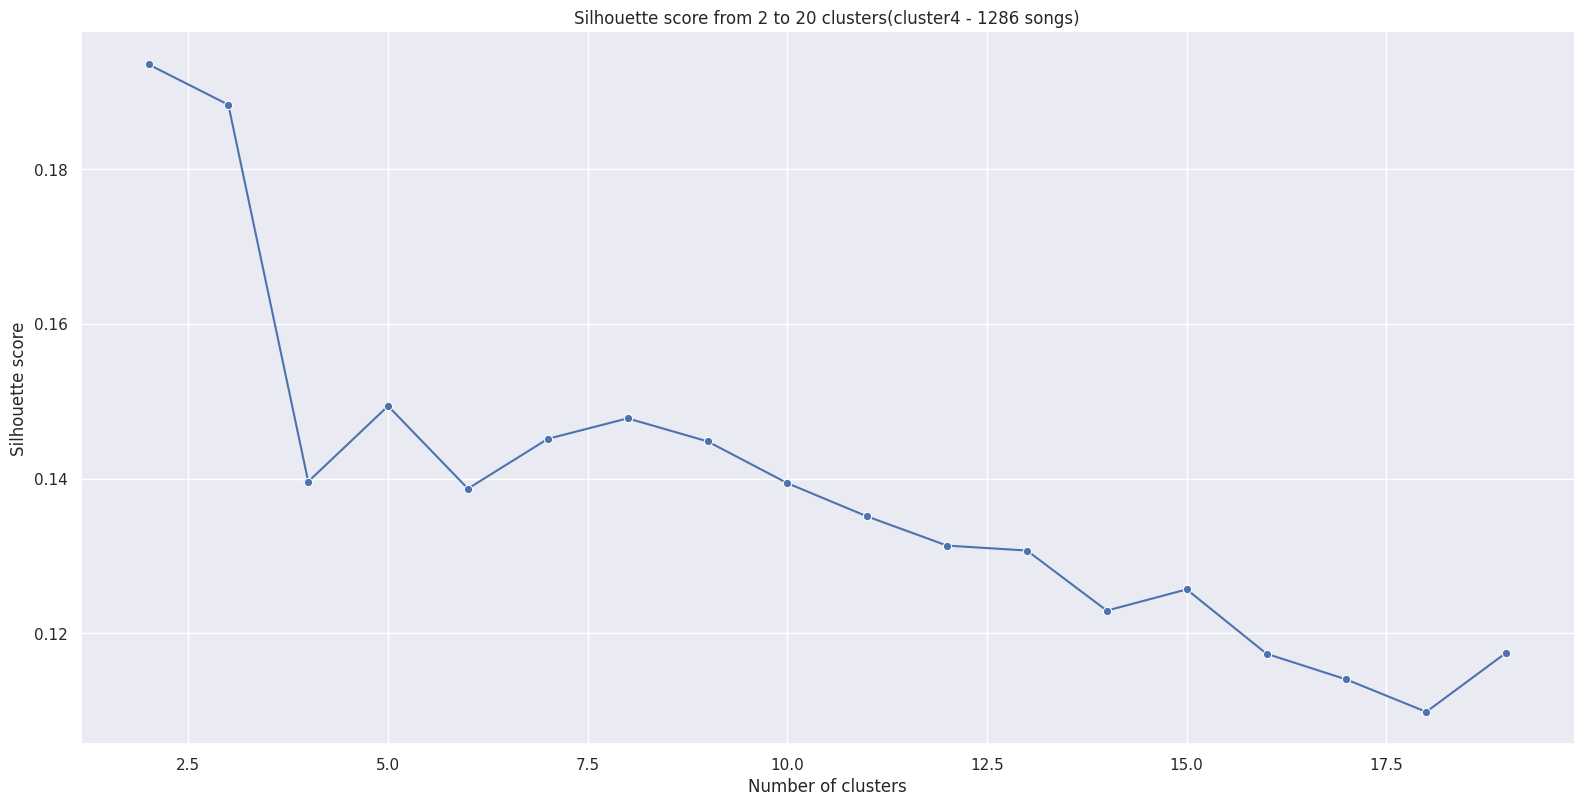

In [ ]:
(
sns.relplot(y = sil_scores_cluster4,
            x = range(2, 20),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 2 to 20 clusters(cluster4 - 1286 songs)")
.set_axis_labels("Number of clusters", "Silhouette score")
);


In [ ]:
# Initialise the model
my_kmeans_cluster4 = KMeans(n_clusters = 7,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster4.fit(cluster4)

# Obtain the cluster output
clusters4_output = my_kmeans_cluster4.labels_

# Attach the cluster output to our original DataFrame
cluster4["cluster"] = clusters4_output

In [ ]:
cluster4['cluster'].value_counts().sort_values()

,count
cluster,
2,133
3,133
4,146
6,161
0,224
1,227
5,262


In [ ]:
cluster4

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
name,artist,,,,,,,,,,,
Saudade De Bahia,Antônio Carlos Jobim,0.541749,-0.807143,-0.868390,0.0,-0.352254,0.212858,-0.003394,-0.124567,0.580042,0.158709,0
Brigas Nunca Mais,Paula Morelenbaum,0.415516,-0.457143,-0.672145,0.0,-0.262104,0.531528,0.112105,0.193772,0.471933,1.343414,3
Previsao,Bossacucanova,0.362919,0.300000,-0.100012,0.0,-0.292154,0.959356,0.540677,0.096886,0.253638,-0.500721,4
Nova Bossa Nova,Marcos Valle,0.163051,0.002381,-0.532440,0.0,-0.175292,0.751604,1.098429,0.145329,0.970894,-0.631769,0
Águas De Março,Antônio Carlos Jobim,0.270874,-0.442857,-0.315980,0.0,1.190317,1.295633,-0.003397,-0.020761,0.124740,0.637984,3
...,...,...,...,...,...,...,...,...,...,...,...,...
There Is More,Lexi,0.110454,-0.628571,-0.165263,0.0,-0.273790,0.836114,-0.003397,-0.103806,-0.010395,0.012889,6
Worth Fighting For - Live,Brian Courtney Wilson,-0.662722,-0.573810,-0.122036,0.0,0.457429,0.013909,-0.003397,-0.421453,-0.401247,1.488681,2
The Potter's House,Jerard & Jovaun,0.173570,-0.423810,-0.009122,0.0,-0.116861,0.036797,-0.003381,0.076125,0.534304,0.341445,0


In [ ]:
cluster4.groupby('cluster').mean()

#Cluster 0 "Happy, Acoustic and Danceable But Calm"

#Cluster 1 "Standard Pop / Alternative Rock"

#Cluster 2 "High-Tempo, Energetic and Vibrant"

#Cluster 3 "Up-Tempo But Calm / Fast Classical"

#Cluster 4 "Slow and Melancholy / Dark Pop"

#Cluster 5 "Groovy / Hip-Hop / R&B / Reggaeton"

#Cluster 6 "Purely Acoustic, Ambient and Relaxing"

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,
0,0.389734,-0.339264,-0.508053,0.0,-0.193164,0.273013,0.085228,-0.108128,0.810254,-0.080971
1,0.147364,0.051815,0.284732,0.0,-0.186353,-0.028400,0.103035,-0.098300,-0.062484,0.261015
2,-0.004311,0.140834,0.162097,0.0,0.078891,0.140709,0.125387,-0.131134,0.680615,1.209794
3,-0.051173,-0.708718,-0.408860,0.0,-0.276300,0.871227,0.046387,0.041335,0.175855,0.749101
4,0.012285,-0.262639,0.073374,0.0,-0.262847,0.158693,0.039498,-0.004313,-0.063640,-0.658465
5,0.539119,0.089776,0.350419,0.0,0.099300,0.071911,0.013077,-0.140429,0.708757,-0.218074
6,0.150849,-0.781795,-0.536184,0.0,-0.210288,1.063178,0.099834,0.018049,0.296045,-0.485154


In [ ]:
playlist_1 = cluster4[cluster4['cluster'] == 0].copy()   # Happy, Acoustic and Danceable But Calm
playlist_2 = cluster4[cluster4['cluster'] == 1].copy()   # Standard Pop / Alternative Rock
playlist_3 = cluster4[cluster4['cluster'] == 2].copy()   # High-Tempo, Energetic and Vibrant
playlist_4 = cluster4[cluster4['cluster'] == 3].copy()   # Up-Tempo But Calm / Fast Classical
playlist_5 = cluster4[cluster4['cluster'] == 4].copy()   # Slow and Melancholy / Dark Pop
playlist_6 = cluster4[cluster4['cluster'] == 5].copy()   # Groovy / Hip-Hop / R&B / Reggaeton
playlist_7 = cluster4[cluster4['cluster'] == 6].copy()   # Purely Acoustic, Ambient and Relaxing

In [ ]:
cluster3_= df_scaled.loc[df_scaled['cluster']==3]

In [ ]:
cluster3 = cluster3_.drop(columns=['cluster'])

In [ ]:
# Create an empty list to store the inertia scores
inertia_list_cluster3 = []

# Iterate over the range of cluster numbers
for k in range(2, 12):

    # Create a KMeans object with the specified number of clusters
    myKMeans = KMeans(n_clusters = k,
                      random_state = 42)

    # Fit the KMeans model to the scaled data
    myKMeans.fit(cluster3)

    # Append the inertia score to the list
    inertia_list_cluster3.append(myKMeans.inertia_)

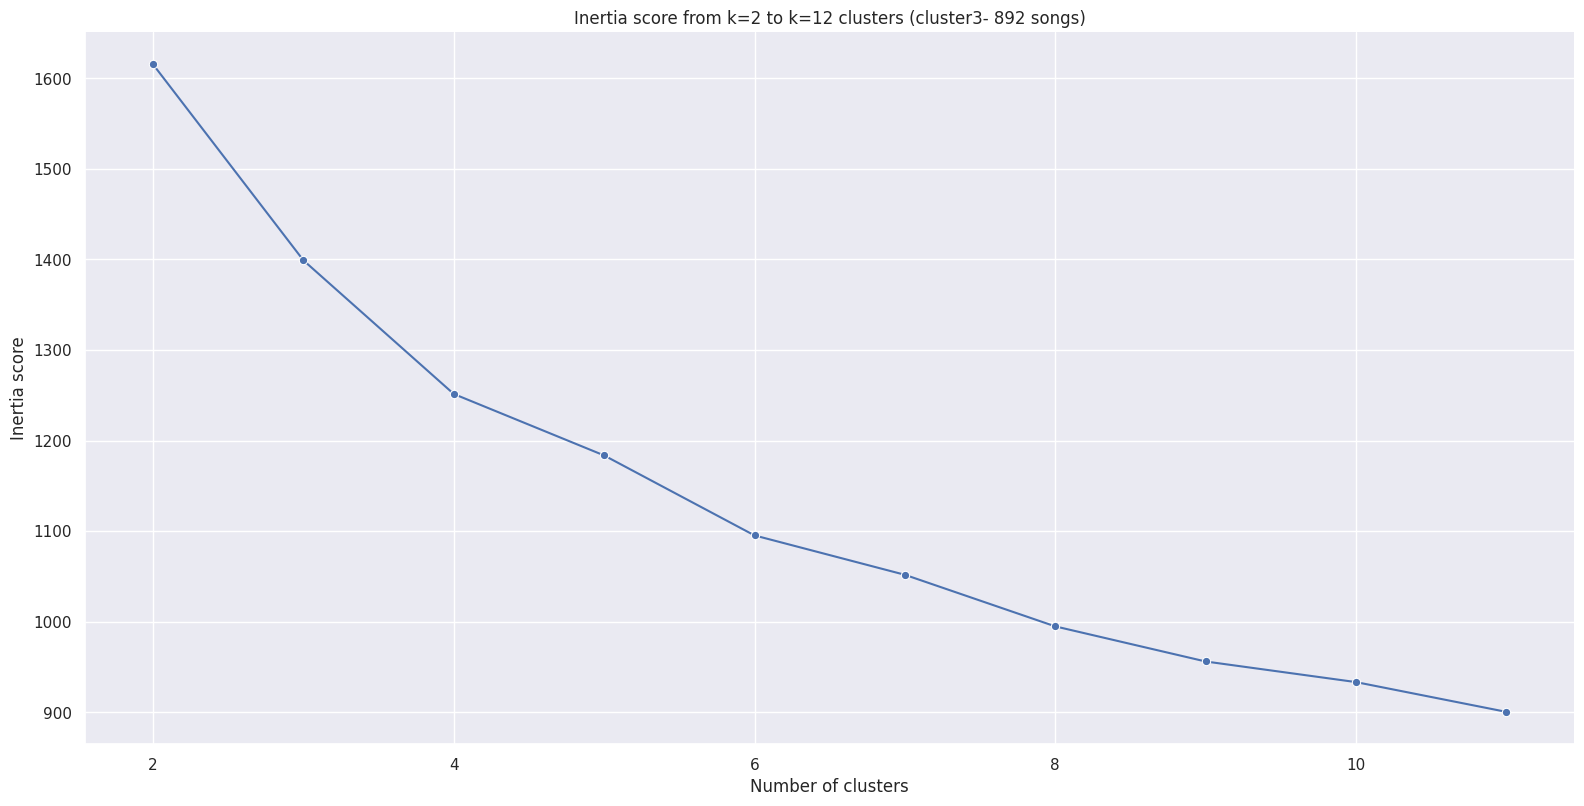

In [ ]:
# making grapf of inertia score
sns.set_theme(style='darkgrid')

(
# Create a line plot of the inertia scores
sns.relplot(y = inertia_list_cluster3,
            x = range(2, 12),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
# Set the title of the plot
.set(title=f"Inertia score from k=2 to k=12 clusters (cluster3- 892 songs)")
# Set the axis labels
.set_axis_labels("Number of clusters", "Inertia score")
);

#k=4 looks like elbow

In [ ]:
# Create an empty list to store the silhouette scores
sil_scores_cluster3 = []

for k in range(2,12):

    # Create a KMeans object with the specified number of clusters
    kmeans = KMeans(n_clusters = k,
                    random_state = 42)

    # Fit the KMeans model to the scaled data
    kmeans.fit(cluster3)

    # Get the cluster labels
    labels = kmeans.labels_

    # Calculate the silhouette score
    sil_score = silhouette_score(cluster3, labels)

    # Append the silhouette score to the list
    sil_scores_cluster3.append(sil_score)

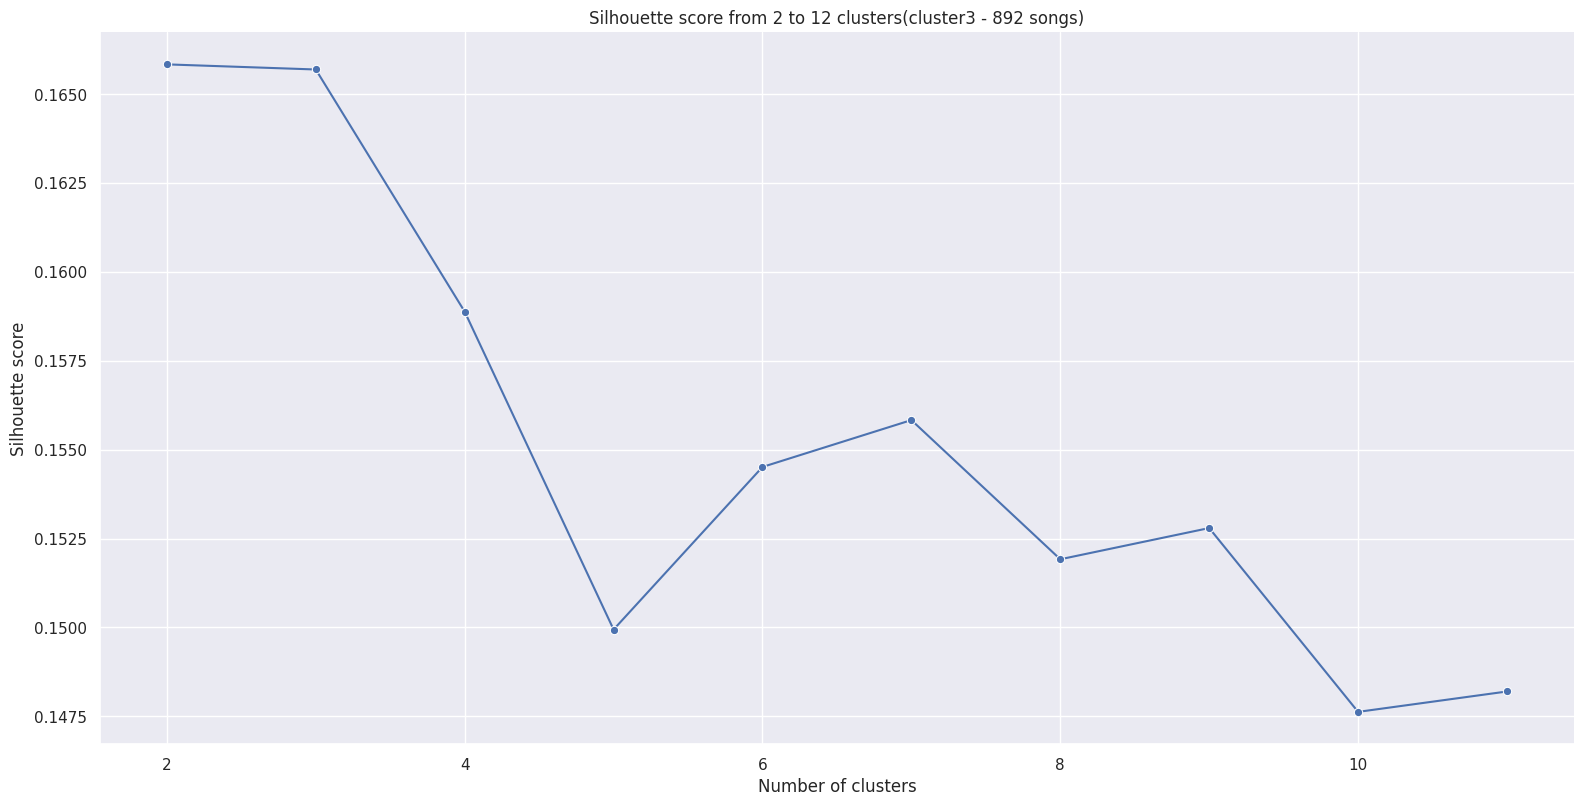

In [ ]:
(
sns.relplot(y = sil_scores_cluster3,
            x = range(2, 12),
            kind = 'line',
            marker = 'o',
            height = 8,
            aspect = 2)
.set(title=f"Silhouette score from 2 to 12 clusters(cluster3 - 892 songs)")
.set_axis_labels("Number of clusters", "Silhouette score")
);


In [ ]:
# Initialise the model
my_kmeans_cluster3 = KMeans(n_clusters = 4,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster3.fit(cluster3)

# Obtain the cluster output
clusters3_output = my_kmeans_cluster3.labels_

# Attach the cluster output to our original DataFrame
cluster3["cluster"] = clusters3_output

In [ ]:
cluster3.groupby('cluster').mean()
#cluster 0 - High-Energy, Vocal-Heavy
#cluster 1 - Doom Metal / Instrumental Death Metal
#cluster 2 - Energetic and Intense Live Performances
#cluster 3 - Rock / Alternative Rock / Indie Rock / Classic Rock

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,
0,-0.677856,0.508104,0.122857,-0.263158,1.123671,-0.161233,0.532422,0.004920,-0.505606,-0.239489
1,-0.683009,0.297113,-0.423645,-0.294776,0.303429,-0.159702,1.179866,0.085289,-0.322095,-0.374667
2,-0.752182,0.446664,-0.131089,-0.329949,0.807581,-0.153544,1.116284,1.280628,-0.442450,0.016287
3,-0.803158,0.429241,-0.122004,-0.381910,0.710070,-0.163010,0.980844,0.023606,-0.388074,1.055413


In [ ]:
cluster3['cluster'].value_counts().sort_values()

,count
cluster,
2,197
3,199
0,228
1,268


In [ ]:
cluster3.loc[cluster3['cluster']==3]

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
name,artist,,,,,,,,,,,
No Children,The Mountain Goats,-0.980934,0.476190,0.376628,-1.0,0.265442,-0.169192,1.426697,1.128028,0.160083,1.612410,3
Talking Backwards,Real Estate,-0.307692,0.338095,0.220816,0.0,-0.427379,-0.117257,1.327913,0.069204,0.222453,0.836808,3
Born to Run,Bruce Springsteen,-0.699540,0.490476,0.519949,0.0,0.697830,-0.160374,-0.003366,-0.062284,0.399168,0.719767,3
Don't Look Back in Anger,Oasis,-0.491782,0.416667,0.617907,0.0,0.223706,-0.115848,-0.003384,-0.034602,-0.392931,1.184718,3
Mr. Brightside,The Killers,-0.486522,0.452381,0.600320,0.0,0.337229,-0.167205,-0.003397,-0.181315,-0.363825,0.764082,3
...,...,...,...,...,...,...,...,...,...,...,...,...
Warriors Trial,Amorphis,-0.973044,0.504762,0.405720,0.0,0.422371,-0.169173,1.273202,-0.307266,-0.636175,0.767452,3
Second Thought,Morta Skuld,-0.854701,0.483333,-0.172823,0.0,0.245409,-0.169020,0.037333,0.352941,-0.328482,1.298651,3
Infection Of Death,Baphomet,-0.778435,0.228571,-0.438920,-1.0,0.515860,-0.167855,1.350709,0.048443,-0.288981,1.572808,3


In [ ]:
playlist_8 = cluster3[cluster3['cluster'] == 0].copy()   #High-Energy, Vocal-Heavy
playlist_9 = cluster3[cluster3['cluster'] == 1].copy()   #Doom Metal / Instrumental Death Metal
playlist_10 = cluster3[cluster3['cluster'] == 2].copy()  #Energetic and Intense Live Performances
playlist_11 = cluster3[cluster3['cluster'] == 3].copy()  #Rock / Alternative Rock / Indie Rock / Classic Rock

In [ ]:
cluster0_= df_scaled.loc[df_scaled['cluster']==0]

In [ ]:
cluster0 = cluster0_.drop(columns=['cluster'])

In [ ]:
# Initialise the model
my_kmeans_cluster0 = KMeans(n_clusters = 4,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster0.fit(cluster0)

# Obtain the cluster output
clusters0_output = my_kmeans_cluster0.labels_

# Attach the cluster output to our original DataFrame
cluster0["cluster"] = clusters0_output

In [ ]:
cluster0.groupby('cluster').mean()

,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,
0,-0.682564,-1.695213,-4.081650,-0.400000,-0.128488,1.526813,1.273203,-0.135398,-0.573200,-0.712470
1,-0.491569,-1.406843,-2.023116,-0.364929,-0.176495,1.453579,1.122043,-0.020164,-0.471211,0.676764
2,-0.697303,-1.451551,-2.134388,-0.367965,-0.209404,1.454321,1.238531,0.037205,-0.616746,-0.980791
3,-0.162705,-1.284926,-1.363864,-0.346491,-0.145872,1.374757,0.304730,0.127739,-0.189763,-0.510644


In [ ]:
cluster0['cluster'].value_counts().sort_values()

,count
cluster,
0,140
1,211
3,228
2,231


In [ ]:
playlist_12 = cluster0[cluster0['cluster'] == 0].copy()   # Classical / Solo Piano & Orchestral
playlist_13 = cluster0[cluster0['cluster'] == 1].copy()   # Bossa Nova/Jazz
playlist_14 = cluster0[cluster0['cluster'] == 2].copy()   # Acoustic Guitar/Ambient & Orchestral
playlist_15 = cluster0[cluster0['cluster'] == 3].copy()   #  Vocal Bossa/Jazz Standards & Grand Orchestral

In [ ]:
cluster1_= df_scaled.loc[df_scaled['cluster']==1]

In [ ]:
cluster1 = cluster1_.drop(columns=['cluster'])

In [ ]:
# Initialise the model
my_kmeans_cluster1 = KMeans(n_clusters = 4,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster1.fit(cluster1)

# Obtain the cluster output
clusters1_output = my_kmeans_cluster1.labels_

# Attach the cluster output to our original DataFrame
cluster1["cluster"] = clusters1_output

In [ ]:
cluster1['cluster'].value_counts().sort_values()

,count
cluster,
2,155
0,181
1,194
3,199


In [ ]:
cluster1.loc[cluster1['cluster']==1]


,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
name,artist,,,,,,,,,,,
Os Grilos,Marcos Valle,0.097304,0.159524,-0.651600,-1.0,0.315526,0.487513,0.739766,-0.287889,0.582121,-0.499826,1
Amiga Da Minha Mulher,Seu Jorge,0.662722,0.423810,0.363315,-1.0,1.090150,1.087881,-0.003397,-0.265052,0.862786,-0.394871,1
"Rosa, Menina Rosa",Jorge Ben Jor,0.126233,-0.230952,-0.008629,-1.0,0.549249,0.492795,-0.003397,-0.048443,0.661123,-0.598961,1
Swing de Campo Grande,Novos Baianos,0.599606,-0.097619,0.002712,-1.0,-0.053422,1.205842,-0.003397,0.262976,1.087318,-0.394844,1
Nomes de Favela,Moyseis Marques,0.570677,-0.528571,-0.375478,-1.0,0.175292,0.485752,-0.003397,-0.417301,0.931393,-0.709446,1
...,...,...,...,...,...,...,...,...,...,...,...,...
Mala Mujer,C. Tangana,0.788955,-0.016667,0.458643,-1.0,1.290484,0.249831,-0.003363,-0.382007,0.122661,-0.474943,1
Mayores,Becky G,0.549638,0.233333,0.497432,-1.0,-0.188648,0.086094,0.001375,-0.062284,0.956341,-0.579766,1
Sin Pijama,Becky G,0.670611,0.016667,0.602786,-1.0,-0.155259,0.454061,-0.003352,-0.145329,0.844075,-0.658206,1


In [ ]:
playlist_16 = cluster1[cluster1['cluster'] == 0].copy()   # MPB/Brazilian Pop & Latin Pop & Gospel
playlist_17 = cluster1[cluster1['cluster'] == 1].copy()   # Samba/MPB & Reggaeton & Gospel
playlist_18 = cluster1[cluster1['cluster'] == 2].copy()   # Bossa Nova/Jazz & Reggaeton
playlist_19 = cluster1[cluster1['cluster'] == 3].copy()   # Indie/Alt-Soul & Reggaeton & Gospel

In [ ]:
cluster7_= df_scaled.loc[df_scaled['cluster']==7]

In [ ]:
cluster7 = cluster7_.drop(columns=['cluster'])

In [ ]:
# Initialise the model
my_kmeans_cluster7 = KMeans(n_clusters = 4,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster7.fit(cluster7)

# Obtain the cluster output
clusters7_output = my_kmeans_cluster7.labels_

# Attach the cluster output to our original DataFrame
cluster7["cluster"] = clusters7_output

In [ ]:
cluster7['cluster'].value_counts().sort_values()

,count
cluster,
1,113
0,124
2,146
3,239


In [ ]:
playlist_20 = cluster7[cluster7['cluster'] == 0].copy()   # Indie/Twee-Pop & Gospel
playlist_21 = cluster7[cluster7['cluster'] == 1].copy()   # Indie/Alt & Reggaeton & Gospel
playlist_22 = cluster7[cluster7['cluster'] == 2].copy()   # Indie/Electronic
playlist_23 = cluster7[cluster7['cluster'] == 3].copy()   # MPB/Samba & Reggaeton

In [ ]:
playlist_23

,,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
name,artist,,,,,,,,,,,
Aqua De Coco,Marcos Valle,0.575937,-0.014286,-0.367753,-1.0,0.168614,0.688222,-0.002014,2.276817,0.835759,-0.815822,3
Samba de Verão,Marcos Valle,0.423406,-0.792857,-1.187410,0.0,-0.400668,1.262181,-0.003158,1.404844,0.896050,-0.110024,3
A Força Que Nunca Seca (feat. Maria Bethânia),Chico César,0.071006,-1.490476,-0.653080,0.0,-0.237062,1.397748,-0.003397,1.439446,-0.212058,-0.280147,3
País Tropical,Wilson Simonal,0.452334,-0.330952,-0.353947,0.0,-0.368948,1.050908,-0.003397,1.183391,1.045738,0.264270,3
Ponto De Marinheiro / Marinheiro Só,Zé Maurício Machline,0.628534,-0.545238,-0.756626,0.0,1.156928,0.814986,-0.003397,1.432526,0.866944,-0.578265,3
...,...,...,...,...,...,...,...,...,...,...,...,...
Soltera - Remix,Lunay,0.681131,0.107143,0.508115,0.0,-0.208681,0.466386,-0.003397,2.159170,0.800416,-0.710973,3
Otra vez (feat. J Balvin),Zion & Lennox,0.778435,0.080952,0.317788,0.0,0.739566,-0.070777,-0.002658,2.179931,0.602911,-0.605491,3
Felices los 4,Maluma,0.604865,0.042857,0.246785,0.0,1.273790,0.205815,-0.003397,1.550173,0.627859,-0.657863,3


In [ ]:
cluster2_= df_scaled.loc[df_scaled['cluster']==2]

In [ ]:
cluster2 = cluster2_.drop(columns=['cluster'])

In [ ]:
# Initialise the model
my_kmeans_cluster2 = KMeans(n_clusters = 3,
                   random_state = 42)

# Fit the model to the data
my_kmeans_cluster2.fit(cluster2)

# Obtain the cluster output
clusters2_output = my_kmeans_cluster2.labels_

# Attach the cluster output to our original DataFrame
cluster2["cluster"] = clusters2_output

In [ ]:
cluster2['cluster'].value_counts().sort_values()

,count
cluster,
0,116
1,166
2,167


In [ ]:
playlist_24 = cluster2[cluster2['cluster'] == 0].copy()   # Rap/Spoken — Extreme Speechiness
playlist_25 = cluster2[cluster2['cluster'] == 1].copy()   # EDM Remixes -Extreme Speechiness
playlist_26 = cluster2[cluster2['cluster'] == 2].copy()   #  Brazilian Experimental & Latin Trap -  Extreme Speechiness


In [ ]:
playlist_27 = df_scaled[df_scaled['cluster'] == 5].copy()  # High-Liveness Mixed: Live Jazz/Bossa

In [ ]:
playlist_28= df_scaled[df_scaled['cluster'] ==6 ].copy()  #Spoken Rhythms, Extreme Speechiness: Brazilian Percussion